<a href="https://colab.research.google.com/github/ampereapescador/Metodos2PereaPescador/blob/main/T5_1b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

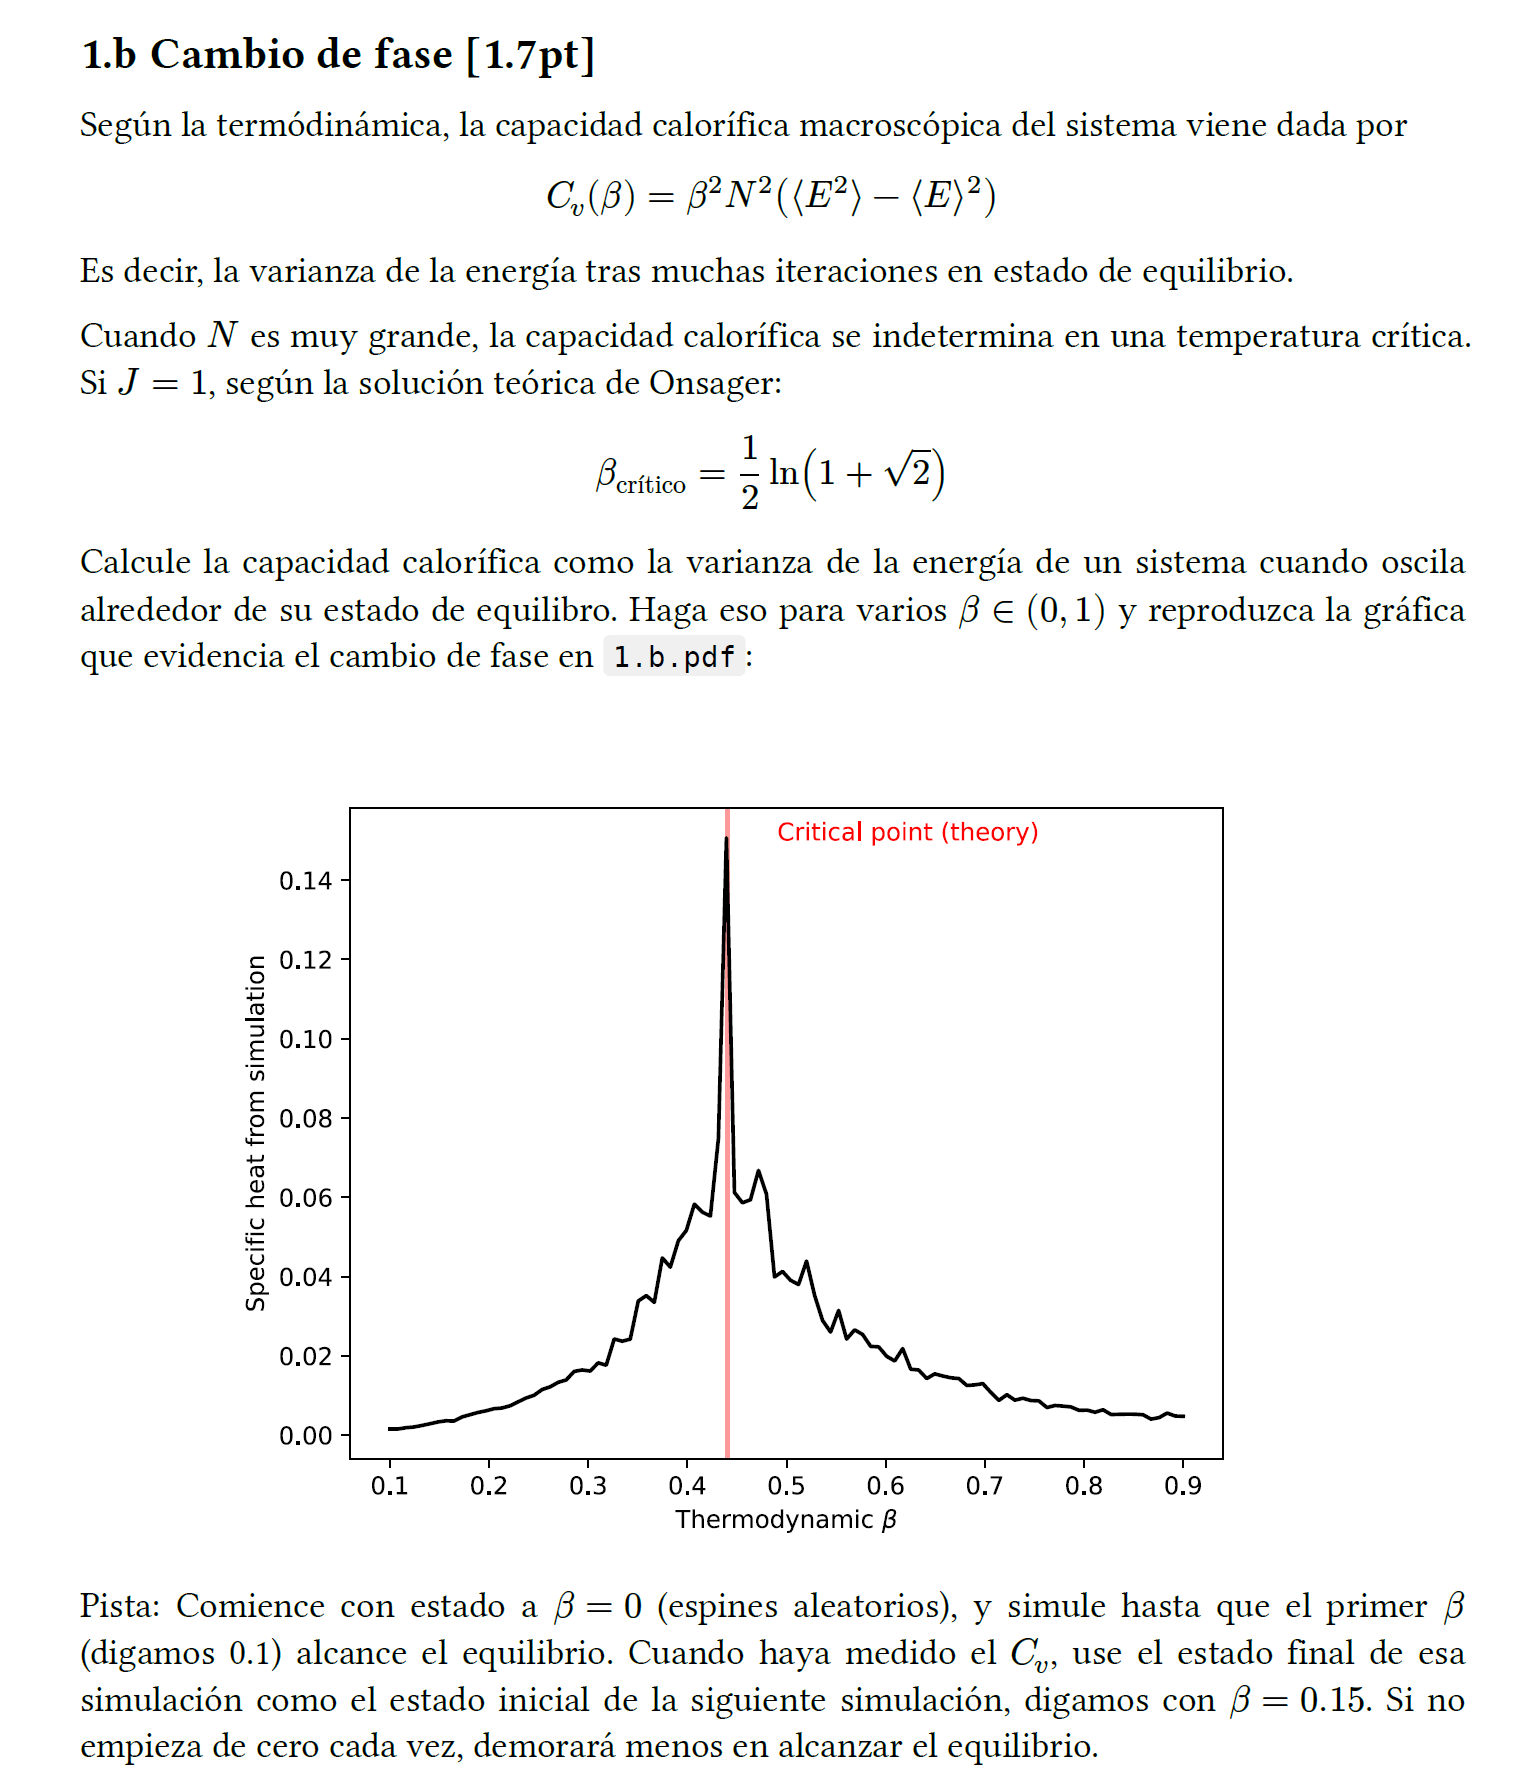

[1/81] beta=0.100  Cv=0.01893  samples=80  time_beta=0.51s
[6/81] beta=0.150  Cv=0.04717  samples=80  time_beta=0.01s
[11/81] beta=0.200  Cv=0.07250  samples=80  time_beta=0.01s
[16/81] beta=0.250  Cv=0.19726  samples=80  time_beta=0.01s
[21/81] beta=0.300  Cv=0.36792  samples=80  time_beta=0.01s
[26/81] beta=0.350  Cv=0.65910  samples=80  time_beta=0.01s
[31/81] beta=0.400  Cv=1.00342  samples=80  time_beta=0.01s
[36/81] beta=0.450  Cv=1.20260  samples=80  time_beta=0.01s
[41/81] beta=0.500  Cv=0.94206  samples=80  time_beta=0.01s
[46/81] beta=0.550  Cv=0.37449  samples=80  time_beta=0.01s
[51/81] beta=0.600  Cv=0.37182  samples=80  time_beta=0.01s
[56/81] beta=0.650  Cv=0.27184  samples=80  time_beta=0.01s
[61/81] beta=0.700  Cv=0.12541  samples=80  time_beta=0.01s
[66/81] beta=0.750  Cv=0.15130  samples=80  time_beta=0.01s
[71/81] beta=0.800  Cv=0.10348  samples=80  time_beta=0.01s
[76/81] beta=0.850  Cv=0.05722  samples=80  time_beta=0.01s
[81/81] beta=0.900  Cv=0.04900  samples=80

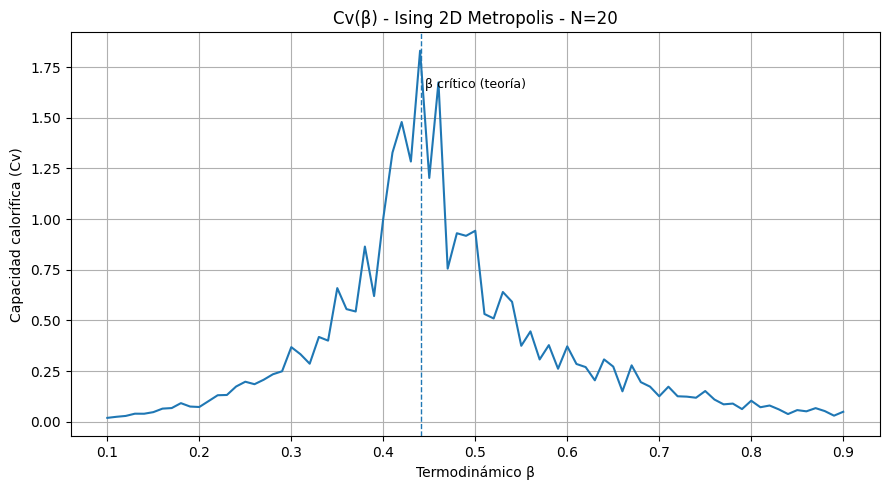

Gráfica guardada en results_ising/cv_vs_beta.png


In [ ]:

# 1b

# Simulación 2D del modelo de Ising usando Metropolis MCMC.
# Calcula la capacidad calorífica Cv(β) = β^2 N^2 ( <E^2> - <E>^2 ) y guarda una gráfica

!pip install numpy matplotlib numba
import time                              # medir tiempo de ejecución
import numpy as np                       # arrays y operaciones vectorizadas
import matplotlib.pyplot as plt          # para graficar
import csv                               # para guardar resultados en CSV
import os                                # operaciones de sistema (crear carpeta)


# Entrada y definición de parámetros

N = 20                                   # Matriz cuadrada (N x N)
J = 1.0                                  # acoplamiento entre vecinos (J>0 ferromagnético)
beta_values = np.arange(0.10, 0.901, 0.01)  # rango de betas a explorar (0.10 a 0.90 paso 0.01)
eq_sweeps = 200                          # sweeps para equilibrar en cada beta
meas_sweeps = 400                        # sweeps durante la etapa de medida
sample_interval = 5                      # guardar muestra cada 'sample_interval' sweeps
output_dir = "results_ising"             # carpeta donde guardar resultados


# Numba: intentamos usarlo para acelerar loops

use_numba = False
try:
    from numba import njit
    use_numba = True
    # Nota: en algunas instalaciones de numba, np.random.random() funciona dentro de @njit;

except Exception as e:
    # Si no está instalado numba, seguimos con la versión numpy/pura.
    print("numba no disponible — se usará la versión numpy (más lenta).", e)


# Funciones

#Inicializamos matriz nxn con espines aleatorios. Entrega un array
def init_spins_random(N):

    # np.random.rand genera valores en [0,1); con <0.5 ponemos 1, sino -1.
    spins = np.where(np.random.rand(N, N) < 0.5, 1, -1).astype(np.int8)
    return spins

#Calculo energía total como suma de vecinos derecha y abajo evitando repeticiones
def total_energy_numpy(spins, J=1.0):

    N = spins.shape[0]
    energy = 0.0
    # bucle doble
    for i in range(N):
        for j in range(N):
            s = spins[i, j]
            # vecinos: derecha (j+1) y abajo (i+1) con condiciones periódicas
            energy -= J * s * (spins[i, (j + 1) % N] + spins[(i + 1) % N, j])
    return energy

# Ahora energía versión numba de total_energy
if use_numba:
    @njit
    def total_energy_numba(spins, J=1.0):
        N = spins.shape[0]
        energy = 0.0
        for i in range(N):
            for j in range(N):
                s = spins[i, j]
                energy -= J * s * (spins[i, (j + 1) % N] + spins[(i + 1) % N, j])
        return energy

# Versión Metropolis sweep (numpy)
def metropolis_sweep_numpy(spins, beta, J=1.0):
    """
    Realiza un sweep de Metropolis: intenta voltear cada espín (orden i,j).
    """
    N = spins.shape[0]
    for i in range(N):
        for j in range(N):
            s = spins[i, j]
            # suma de los 4 vecinos (periodic boundary conditions)
            nb = spins[(i - 1) % N, j] + spins[(i + 1) % N, j] + spins[i, (j - 1) % N] + spins[i, (j + 1) % N]
            dE = 2.0 * J * s * nb   # cambio de energia al voltear s -> -s
            # criterio de Metropolis
            if dE <= 0.0:
                spins[i, j] = -s
            else:
                if np.random.rand() < np.exp(-beta * dE):
                    spins[i, j] = -s

# Versión Metropolis sweep (numba)
if use_numba:
    @njit
    def metropolis_sweep_numba(spins, beta, J=1.0):
        N = spins.shape[0]
        for i in range(N):
            for j in range(N):
                s = spins[i, j]
                nb = spins[(i - 1) % N, j] + spins[(i + 1) % N, j] + spins[i, (j - 1) % N] + spins[i, (j + 1) % N]
                dE = 2.0 * J * s * nb
                if dE <= 0.0:
                    spins[i, j] = -s
                else:
                    # np.random.random() en numba genera un float en [0,1)
                    if np.random.random() < np.exp(-beta * dE):
                        spins[i, j] = -s

# Selección numba o numpy
if use_numba:
    total_energy = total_energy_numba
    metropolis_sweep = metropolis_sweep_numba
else:
    total_energy = total_energy_numpy
    metropolis_sweep = metropolis_sweep_numpy


# Cálculo del betha (Onsager) para J=1

beta_crit_theory = 0.5 * np.log(1.0 + np.sqrt(2.0))


# Simulacion: recorre bethas, equilibra, medida. Devuelve arrays (betas, Cv_list)

def run_simulation(N, J, beta_values, eq_sweeps, meas_sweeps, sample_interval):

    # Inicializamos resultados
    Cv_list = []
    betas_done = []
    # Crear estado inicial aleatorio (equivalente a betha 0)
    spins = init_spins_random(N)
    start_total = time.time()

    # iteramos sobre betas
    for idx, beta in enumerate(beta_values):
        t0 = time.time()
        # 1) equilibración: eq_sweeps sweeps sin medir
        for _ in range(eq_sweeps):
            metropolis_sweep(spins, beta, J)

        # 2) medición: realizamos meas_sweeps y guardamos muestras cada sample_interval
        energies = []  # energías por espín muestreadas
        for sweep in range(meas_sweeps):
            metropolis_sweep(spins, beta, J)
            if (sweep % sample_interval) == 0:
                # total_energy devuelve energía total; convertimos a energía por espín
                E_per_spin = total_energy(spins, J) / (N * N)
                energies.append(E_per_spin)

        energies = np.array(energies, dtype=np.float64)
        # calcular momentos
        E_mean = energies.mean()
        E2_mean = (energies ** 2).mean()
        # formula del enunciado: Cv = beta^2 * N^2 * ( <E^2> - <E>^2 )
        Cv = (beta ** 2) * (N ** 2) * (E2_mean - E_mean ** 2)
        Cv_list.append(Cv)
        betas_done.append(beta)

        t1 = time.time()
        # imprimir progreso cada 5 betas o en el ultimo
        if idx % 5 == 0 or idx == len(beta_values) - 1:
            print(f"[{idx+1}/{len(beta_values)}] beta={beta:.3f}  Cv={Cv:.5f}  samples={len(energies)}  time_beta={t1-t0:.2f}s")

    total_time = time.time() - start_total
    print(f"Simulación completa en {total_time:.1f}s. N={N}, eq_sweeps={eq_sweeps}, meas_sweeps={meas_sweeps}")
    return np.array(betas_done), np.array(Cv_list)


# Resultados

def save_results(output_dir, betas, cv_values):

    # crear carpeta si no existe
    os.makedirs(output_dir, exist_ok=True)
    # Guarda CSV con beta, Cv y grafica png.
    csv_path = os.path.join(output_dir, "cv_vs_beta.csv")
    png_path = os.path.join(output_dir, "cv_vs_beta.png")

    # guardar CSV
    with open(csv_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["beta", "Cv"])
        for b, c in zip(betas, cv_values):
            writer.writerow([f"{b:.6f}", f"{c:.12f}"])
    print(f"Resultados guardados en {csv_path}")

    # plot
    plt.figure(figsize=(9,5))
    plt.plot(betas, cv_values, marker=None)                  # trazo principal
    plt.axvline(beta_crit_theory, linestyle="--", linewidth=1.0)  # vertical beta teórico
    # etiqueta cerca del pico (ajustable)
    plt.text(beta_crit_theory + 0.005, max(cv_values) * 0.9, "β crítico (teoría)", fontsize=9)
    plt.xlabel("Termodinámico β")
    plt.ylabel("Capacidad calorífica (Cv)")
    plt.title(f"Cv(β) - Ising 2D Metropolis - N={N}")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(png_path, dpi=200)

    print(f"Gráfica guardada en {png_path}")


# MAIN: ejecutar simulación y guardar resultados

if __name__ == "__main__":
    # correr simulación
    betas_arr, Cv_arr = run_simulation(N, J, beta_values, eq_sweeps, meas_sweeps, sample_interval)
    # guardar resultados y graficar
    save_results(output_dir, betas_arr, Cv_arr)
